In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib  # Optional: For saving the best model

In [7]:
# Load the dataset directly from sklearn
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)

# Display the first few rows to inspect the data
print("Dataset Preview:")
display(df.head())

# Separate Features (X) and Target Variable (y)
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

Dataset Preview:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature scaling complete. All features now have a common scale.")

Feature scaling complete. All features now have a common scale.


In [9]:
# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 16512
Testing set size: 4128


In [10]:
# Define models to compare
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=5)
}

results = {}

# Loop through models, train, and evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    # UPDATED: Calculate MSE first, then take the square root for RMSE
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, predictions)

    results[name] = {
        "RMSE": round(rmse, 4),
        "R2 Score": round(r2, 4)
    }

# Display Comparison Table
results_df = pd.DataFrame(results).T
print("\nModel Performance Comparison Table:")
display(results_df)


Model Performance Comparison Table:


,RMSE,R2 Score
Linear Regression,0.7456,0.5758
Ridge Regression,0.7456,0.5758
Decision Tree,0.7242,0.5997


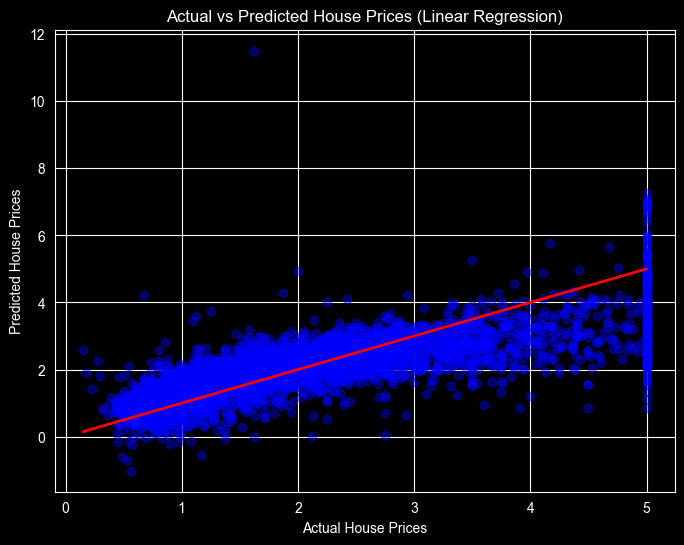

In [11]:
# Visualizing results for the baseline model (Linear Regression)
best_model = LinearRegression()
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", lw=2)
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices (Linear Regression)")
plt.grid(True)
plt.show()

# Optional: Save the best performing model
# joblib.dump(best_model, '../models/house_price_model.joblib')

In [12]:
import joblib
import os

# Create the folder if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Assuming Linear Regression was your best model
joblib.dump(best_model, '../models/house_price_model.joblib')
print("Model saved to models/ folder!")

Model saved to models/ folder!


In [13]:
# Create the reports folder
os.makedirs('../reports', exist_ok=True)

# Save the comparison table
results_df.to_csv('../reports/model_performance_report.csv')
print("Performance report saved to reports/ folder!")

Performance report saved to reports/ folder!


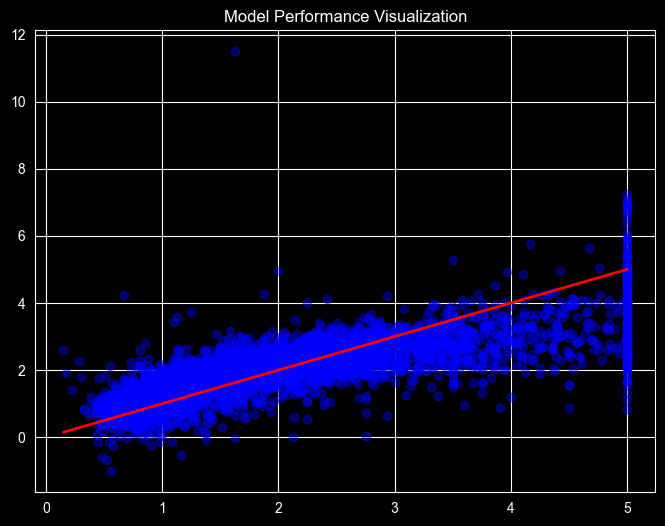

In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", lw=2)
plt.title("Model Performance Visualization")

# Save the plot
plt.savefig('../reports/performance_chart.png')
plt.show()